# 04 - Classification: model evaluation and selection

Six classifiers x 2 imbalance settings (raw vs SMOTE), then hyperparameter tuning and repeated cross-validation to pick one final model.

Protocol, in order:

1. Stratified 75/25 split. `StandardScaler` and SMOTE sit inside the pipeline, so every fold fits them on training data only.
2. **Default hyperparameters** on the held-out test set: `metrics_comparison.csv`, confusion matrices, ROC curves.
3. **`RandomizedSearchCV`** per model and setting, scored on F1 by inner 5-fold CV, fitted on the training split only: `tuning_results.csv`.
4. **`RepeatedStratifiedKFold(5, 10)`** gives 50 estimates per configuration, for both default and tuned settings on both imbalance arms: `cv_comparison.csv`. This is the selection table.
5. Winner chosen on repeated-CV F1 mean, then persisted.

Small-n caveat: only 76 defaults exist, so one split holds about 19 of them and its ranks are noisy. The 50 estimates in step 4 are what make the ranking defensible; the single split is kept as a readable reference, not as the selection basis.

SVM is wrapped in `CalibratedClassifierCV(..., ensemble=False)` because `SVC(probability=True)` is deprecated in scikit-learn 1.9 and removed in 1.11, and the ROC and PR curves need probabilities.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme()
plt.rcParams.update({"axes.titlesize": 13, "axes.titleweight": "semibold"})
GOOD, DEFAULT = "#2e7cb6", "#d65f2c"
MODEL_COLORS = {"DecisionTree": "#4e79a7", "NaiveBayes": "#f28e2b", "RandomForest": "#59a14f", "SVM": "#e15759", "KNN": "#76b7b2", "GradientBoosting": "#edc948"}
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import (RandomizedSearchCV, RepeatedStratifiedKFold,
                                     StratifiedKFold, ValidationCurveDisplay, cross_validate,
                                     train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import joblib

SEED = 42
SCORING = ["f1", "average_precision", "roc_auc"]
ROOT = Path("..") if Path("../data").exists() else Path(".")
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

f = pd.read_csv(DATA_DIR / "loan_features.csv")
DROP = {"loan_id", "account_id", "client_id", "district_id", "status", "date", "parsed_date", "gender", "target"}
X = f.drop(columns=[c for c in DROP if c in f.columns])
y = f["target"]
print(X.shape, "features:", list(X.columns))


def model_zoo():
    """Fresh estimator instances per call, so no object is ever fitted twice."""
    return {
        "DecisionTree": DecisionTreeClassifier(random_state=SEED),
        "NaiveBayes": GaussianNB(),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED),
        "SVM": CalibratedClassifierCV(SVC(random_state=SEED), ensemble=False, cv=3),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "GradientBoosting": GradientBoostingClassifier(random_state=SEED),
    }


def mk(clf, sm=False):
    """Scaler and resampler inside the pipeline, and `clone` so the baseline and
    SMOTE runs never share one fitted estimator object."""
    steps = [StandardScaler()]
    if sm:
        steps.append(SMOTE(random_state=SEED))
    steps.append(clone(clf))
    return make_imb_pipeline(*steps) if sm else make_pipeline(*steps)


models = model_zoo()

(682, 18) features: ['amount', 'duration', 'payments', 'n_txn', 'n_deposit', 'n_withdrawal', 'sum_deposit', 'sum_withdrawal', 'avg_amount', 'std_amount', 'avg_balance', 'min_balance', 'max_balance', 'balance_at_loan', 'months_active', 'txn_per_month', 'age', 'gender_bin']


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
print("train:", X_train.shape, "defaults:", int(y_train.sum()))
print("test: ", X_test.shape, "defaults:", int(y_test.sum()))

train: (511, 18) defaults: 57
test:  (171, 18) defaults: 19


In [3]:
# Step 2 - default hyperparameters, single stratified split (reference table)
results, fitted = [], {}
for name, clf in model_zoo().items():
    for setting, pipe in [("baseline", mk(clf)), ("smote", mk(clf, True))]:
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        proba = pipe.predict_proba(X_test)[:, 1]
        results.append({
            "model": name, "setting": setting,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "average_precision": average_precision_score(y_test, proba),
            "roc_auc": roc_auc_score(y_test, proba),
        })
        fitted[(name, setting)] = (pred, proba, pipe)

res = pd.DataFrame(results).round(3).sort_values(["setting", "f1"], ascending=[True, False])
print(res.to_string(index=False))
res.to_csv(OUT_DIR / "metrics_comparison.csv", index=False)

           model  setting  accuracy  precision  recall    f1  average_precision  roc_auc
    RandomForest baseline     0.924      0.875   0.368 0.519              0.582    0.856
    DecisionTree baseline     0.895      0.529   0.474 0.500              0.309    0.711
GradientBoosting baseline     0.912      0.700   0.368 0.483              0.583    0.816
             SVM baseline     0.918      0.857   0.316 0.462              0.551    0.771
      NaiveBayes baseline     0.807      0.150   0.158 0.154              0.171    0.634
             KNN baseline     0.895      1.000   0.053 0.100              0.220    0.668
GradientBoosting    smote     0.889      0.500   0.421 0.457              0.495    0.741
    DecisionTree    smote     0.883      0.471   0.421 0.444              0.262    0.681
    RandomForest    smote     0.895      0.538   0.368 0.438              0.532    0.826
             SVM    smote     0.854      0.375   0.474 0.419              0.385    0.726
             KNN    s

In [4]:
# Step 3 - hyperparameter search spaces, keyed by pipeline step name
GRID = {
    "DecisionTree": {
        "decisiontreeclassifier__max_depth": [1, 2, 3, 4, 5, 8, 12, 20],
        "decisiontreeclassifier__min_samples_leaf": [1, 2, 5, 10, 20],
        "decisiontreeclassifier__criterion": ["gini", "entropy"],
        "decisiontreeclassifier__class_weight": [None, "balanced"],
    },
    "NaiveBayes": {
        "gaussiannb__var_smoothing": np.logspace(-11, -7, 9),
    },
    "RandomForest": {
        "randomforestclassifier__n_estimators": [100, 200, 300, 500],
        "randomforestclassifier__max_depth": [3, 5, 8, 12, 20],
        "randomforestclassifier__min_samples_leaf": [1, 2, 5, 10],
        "randomforestclassifier__max_features": ["sqrt", "log2", 0.5],
    },
    "SVM": {
        "calibratedclassifiercv__estimator__C": [0.1, 1, 10, 100, 1000],
        "calibratedclassifiercv__estimator__gamma": ["scale", 0.01, 0.1, 1],
        "calibratedclassifiercv__estimator__kernel": ["rbf", "linear"],
    },
    "KNN": {
        "kneighborsclassifier__n_neighbors": [3, 5, 7, 11, 15, 21],
        "kneighborsclassifier__weights": ["uniform", "distance"],
        "kneighborsclassifier__p": [1, 2],
    },
    "GradientBoosting": {
        "gradientboostingclassifier__n_estimators": [100, 200, 300],
        "gradientboostingclassifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "gradientboostingclassifier__max_depth": [1, 2, 3],
        "gradientboostingclassifier__subsample": [0.7, 1.0],
    },
}
for name, grid in GRID.items():
    print(f"{name:17s} {int(np.prod([len(v) for v in grid.values()])):6d} combinations")

DecisionTree         160 combinations
NaiveBayes             9 combinations
RandomForest         240 combinations
SVM                   40 combinations
KNN                   24 combinations
GradientBoosting      72 combinations


In [5]:
# Step 3 - RandomizedSearchCV on the TRAINING split only; the test set stays untouched
INNER = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
searches, search_rows = {}, []
for name in model_zoo():
    combos = int(np.prod([len(v) for v in GRID[name].values()]))
    for setting in ["baseline", "smote"]:
        t0 = time.perf_counter()
        rs = RandomizedSearchCV(mk(model_zoo()[name], setting == "smote"), GRID[name],
                                n_iter=min(30, combos), scoring="f1", cv=INNER,
                                random_state=SEED, n_jobs=-1, refit=True)
        rs.fit(X_train, y_train)
        searches[(name, setting)] = rs
        pretty = "; ".join(f"{k.split('__')[-1]}={v}" for k, v in rs.best_params_.items())
        search_rows.append({
            "model": name, "setting": setting, "n_candidates": min(30, combos),
            "inner_cv_f1": round(float(rs.best_score_), 3), "best_params": pretty,
            "search_seconds": round(time.perf_counter() - t0, 1),
        })
        print(f"{name:17s} {setting:8s} n_iter={min(30, combos):3d} "
              f"inner F1={rs.best_score_:.3f}  {time.perf_counter() - t0:5.1f}s  {pretty}")

tune_res = pd.DataFrame(search_rows).sort_values("inner_cv_f1", ascending=False)
print()
print(tune_res.to_string(index=False))
tune_res.to_csv(OUT_DIR / "tuning_results.csv", index=False)

DecisionTree      baseline n_iter= 30 inner F1=0.492    3.2s  min_samples_leaf=5; max_depth=3; criterion=gini; class_weight=None


DecisionTree      smote    n_iter= 30 inner F1=0.510    0.7s  min_samples_leaf=2; max_depth=12; criterion=gini; class_weight=None
NaiveBayes        baseline n_iter=  9 inner F1=0.371    0.1s  var_smoothing=1e-11
NaiveBayes        smote    n_iter=  9 inner F1=0.321    0.1s  var_smoothing=1e-11


RandomForest      baseline n_iter= 30 inner F1=0.519    3.8s  n_estimators=200; min_samples_leaf=1; max_features=log2; max_depth=8


RandomForest      smote    n_iter= 30 inner F1=0.576    5.4s  n_estimators=200; min_samples_leaf=5; max_features=sqrt; max_depth=20


SVM               baseline n_iter= 30 inner F1=0.503    8.5s  kernel=rbf; gamma=0.01; C=0.1


SVM               smote    n_iter= 30 inner F1=0.530   18.1s  kernel=linear; gamma=0.01; C=100
KNN               baseline n_iter= 24 inner F1=0.229    0.1s  weights=uniform; p=2; n_neighbors=3


KNN               smote    n_iter= 24 inner F1=0.385    0.1s  weights=distance; p=2; n_neighbors=21


GradientBoosting  baseline n_iter= 30 inner F1=0.582    3.0s  subsample=0.7; n_estimators=300; max_depth=1; learning_rate=0.05


GradientBoosting  smote    n_iter= 30 inner F1=0.538    5.8s  subsample=0.7; n_estimators=300; max_depth=2; learning_rate=0.05

           model  setting  n_candidates  inner_cv_f1                                                           best_params  search_seconds
GradientBoosting baseline            30        0.582      subsample=0.7; n_estimators=300; max_depth=1; learning_rate=0.05             3.0
    RandomForest    smote            30        0.576 n_estimators=200; min_samples_leaf=5; max_features=sqrt; max_depth=20             5.4
GradientBoosting    smote            30        0.538      subsample=0.7; n_estimators=300; max_depth=2; learning_rate=0.05             5.8
             SVM    smote            30        0.530                                      kernel=linear; gamma=0.01; C=100            18.1
    RandomForest baseline            30        0.519  n_estimators=200; min_samples_leaf=1; max_features=log2; max_depth=8             3.8
    DecisionTree    smote            3

In [6]:
# Step 4 - repeated stratified CV: 50 estimates per configuration, both arms, both variants
OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
cv_rows = []
for name in model_zoo():
    for setting in ["baseline", "smote"]:
        for variant in ["default", "tuned"]:
            pipe = mk(model_zoo()[name], setting == "smote")
            if variant == "tuned":
                pipe.set_params(**searches[(name, setting)].best_params_)
            s = cross_validate(pipe, X, y, cv=OUTER, scoring=SCORING, n_jobs=-1)
            cv_rows.append({
                "model": name, "setting": setting, "variant": variant,
                "cv_f1_mean": round(float(s["test_f1"].mean()), 3),
                "cv_f1_std": round(float(s["test_f1"].std()), 3),
                "cv_ap_mean": round(float(s["test_average_precision"].mean()), 3),
                "cv_ap_std": round(float(s["test_average_precision"].std()), 3),
                "cv_auc_mean": round(float(s["test_roc_auc"].mean()), 3),
                "cv_auc_std": round(float(s["test_roc_auc"].std()), 3),
            })
            print(f"cv {name:17s} {setting:8s} {variant:7s} "
                  f"F1={cv_rows[-1]['cv_f1_mean']:.3f}+/-{cv_rows[-1]['cv_f1_std']:.3f}")

cv_res = pd.DataFrame(cv_rows).sort_values(["variant", "cv_f1_mean"], ascending=[True, False])
print()
print(cv_res.to_string(index=False))
cv_res.to_csv(OUT_DIR / "cv_comparison.csv", index=False)

cv DecisionTree      baseline default F1=0.491+/-0.090
cv DecisionTree      baseline tuned   F1=0.557+/-0.126


cv DecisionTree      smote    default F1=0.452+/-0.107


cv DecisionTree      smote    tuned   F1=0.464+/-0.104
cv NaiveBayes        baseline default F1=0.325+/-0.132
cv NaiveBayes        baseline tuned   F1=0.325+/-0.132


cv NaiveBayes        smote    default F1=0.318+/-0.055


cv NaiveBayes        smote    tuned   F1=0.318+/-0.055


...

cv KNN               smote    tuned   F1=0.367+/-0.065


cv GradientBoosting  baseline default F1=0.557+/-0.118


cv GradientBoosting  baseline tuned   F1=0.571+/-0.120


cv GradientBoosting  smote    default F1=0.542+/-0.099


cv GradientBoosting  smote    tuned   F1=0.536+/-0.101

           model  setting variant  cv_f1_mean  cv_f1_std  cv_ap_mean  cv_ap_std  cv_auc_mean  cv_auc_std
    RandomForest baseline default       0.557      0.117       0.659      0.099        0.878       0.047
GradientBoosting baseline default       0.557      0.118       0.636      0.102        0.844       0.052
GradientBoosting    smote default       0.542      0.099       0.632      0.099        0.845       0.053
    RandomForest    smote default       0.537      0.121       0.633      0.103        0.870       0.044
    DecisionTree baseline default       0.491      0.090       0.307      0.073        0.720       0.056
    DecisionTree    smote default       0.452      0.107       0.275      0.082        0.717       0.073
             SVM    smote default       0.436      0.121       0.492      0.120        0.823       0.062
             SVM baseline default       0.421      0.150       0.578      0.105        0.843       0.057

In [7]:
# Step 5 - selection on repeated-CV F1, then persist the winner
ranked = cv_res[cv_res["variant"] == "tuned"].sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
win, runner = ranked.iloc[0], ranked.iloc[1]
same_default = cv_res.query("model == @win['model'] and setting == @win['setting'] and variant == 'default'").iloc[0]
print("=== tuned configurations, ranked by repeated-CV F1 (50 estimates each) ===")
print(ranked[["model", "setting", "cv_f1_mean", "cv_f1_std", "cv_ap_mean", "cv_auc_mean"]].to_string(index=False))
print(f"\nwinner                : {win['model']} ({win['setting']})  F1 {win['cv_f1_mean']:.3f} +/- {win['cv_f1_std']:.3f}"
      f"  AP {win['cv_ap_mean']:.3f}  AUC {win['cv_auc_mean']:.3f}")
print(f"runner-up             : {runner['model']} ({runner['setting']})  F1 {runner['cv_f1_mean']:.3f}"
      f"   margin {win['cv_f1_mean'] - runner['cv_f1_mean']:+.3f}")
print(f"same config, defaults : F1 {same_default['cv_f1_mean']:.3f}"
      f"   tuning gain {win['cv_f1_mean'] - same_default['cv_f1_mean']:+.3f}")

win_name, win_setting = win["model"], win["setting"]
final_pipe = mk(model_zoo()[win_name], win_setting == "smote")
final_pipe.set_params(**searches[(win_name, win_setting)].best_params_)
final_pipe.fit(X_train, y_train)
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
pickle_path = OUT_DIR / "models" / f"best_{win_name}_{win_setting}_tuned.pkl"
joblib.dump(final_pipe, pickle_path)
print(f"\nsaved {pickle_path.name} (fitted on the training split only, so the reported test metrics stay reproducible)")

=== tuned configurations, ranked by repeated-CV F1 (50 estimates each) ===
           model  setting  cv_f1_mean  cv_f1_std  cv_ap_mean  cv_auc_mean
GradientBoosting baseline       0.571      0.120       0.654        0.864
    DecisionTree baseline       0.557      0.126       0.507        0.748
    RandomForest baseline       0.556      0.112       0.661        0.877
    RandomForest    smote       0.542      0.103       0.638        0.872
GradientBoosting    smote       0.536      0.101       0.641        0.851
             SVM baseline       0.498      0.128       0.603        0.842
    DecisionTree    smote       0.464      0.104       0.307        0.741
             SVM    smote       0.463      0.084       0.608        0.848
             KNN    smote       0.367      0.065       0.367        0.768
      NaiveBayes baseline       0.325      0.132       0.356        0.769
      NaiveBayes    smote       0.318      0.055       0.338        0.729
             KNN baseline       0.223


saved best_GradientBoosting_baseline_tuned.pkl (fitted on the training split only, so the reported test metrics stay reproducible)


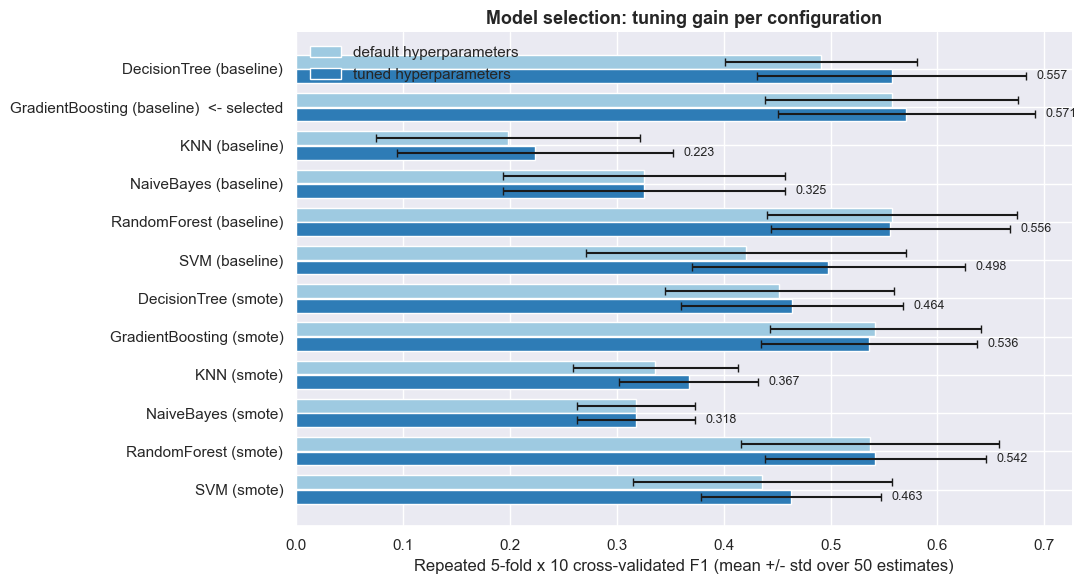

In [8]:
# Step 4 figure - the selection evidence
pivot = cv_res.pivot_table(index=["setting", "model"], columns="variant", values="cv_f1_mean").reset_index()
spread = cv_res.pivot_table(index=["setting", "model"], columns="variant", values="cv_f1_std").reset_index()
labels = [f"{r.model} ({r.setting})" + ("  <- selected" if (r.model, r.setting) == (win_name, win_setting) else "")
          for r in pivot.itertuples()]
ypos = np.arange(len(pivot))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(ypos - 0.19, pivot["default"], height=0.36, xerr=spread["default"], capsize=3,
        color="#9ecae1", edgecolor="white", label="default hyperparameters")
ax.barh(ypos + 0.19, pivot["tuned"], height=0.36, xerr=spread["tuned"], capsize=3,
        color=GOOD, edgecolor="white", label="tuned hyperparameters")
ax.set_yticks(ypos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Repeated 5-fold x 10 cross-validated F1 (mean +/- std over 50 estimates)")
ax.set_title("Model selection: tuning gain per configuration")
ax.legend(frameon=False)
for i, v in enumerate(pivot["tuned"]):
    ax.text(v + spread["tuned"].iloc[i] + 0.01, i + 0.19, f"{v:.3f}", va="center", fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_selection.png", dpi=150, bbox_inches="tight")
plt.show()

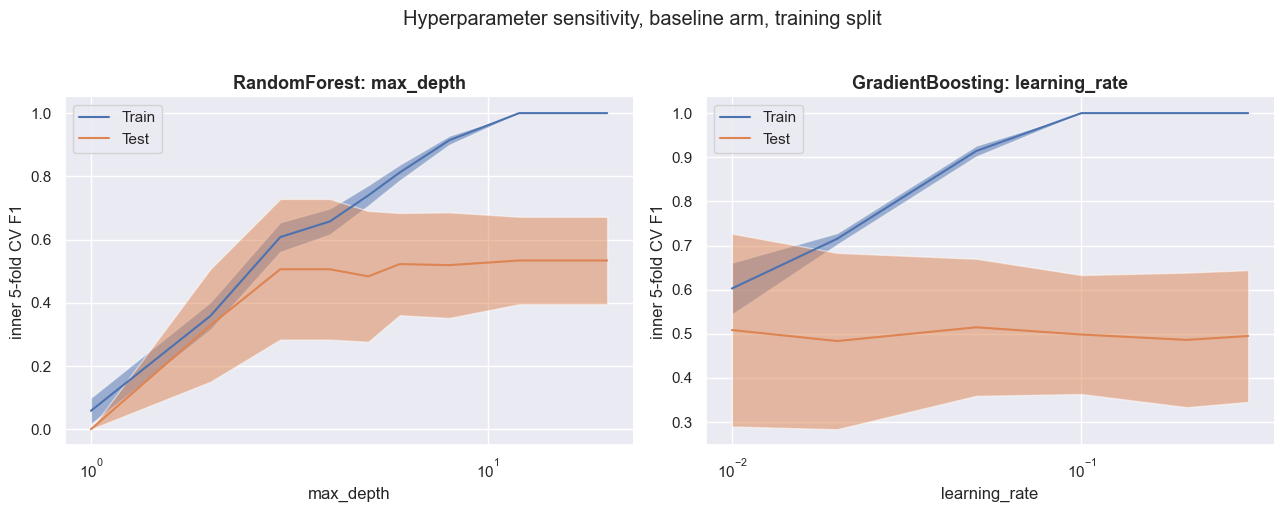

In [9]:
# Step 3 figure - F1 sensitivity to the two hyperparameters that matter most
CURVES = {
    "RandomForest": ("randomforestclassifier__max_depth", [1, 2, 3, 4, 5, 6, 8, 12, 20]),
    "GradientBoosting": ("gradientboostingclassifier__learning_rate", [0.01, 0.02, 0.05, 0.1, 0.2, 0.3]),
}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, (param, values)) in zip(axes, CURVES.items()):
    label = param.split("__")[-1]
    ValidationCurveDisplay.from_estimator(mk(model_zoo()[name]), X_train, y_train,
                                          param_name=param, param_range=values,
                                          cv=INNER, scoring="f1", n_jobs=-1, ax=ax)
    ax.set_title(f"{name}: {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("inner 5-fold CV F1")
    sns.despine(ax=ax)
fig.suptitle("Hyperparameter sensitivity, baseline arm, training split", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "tuning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

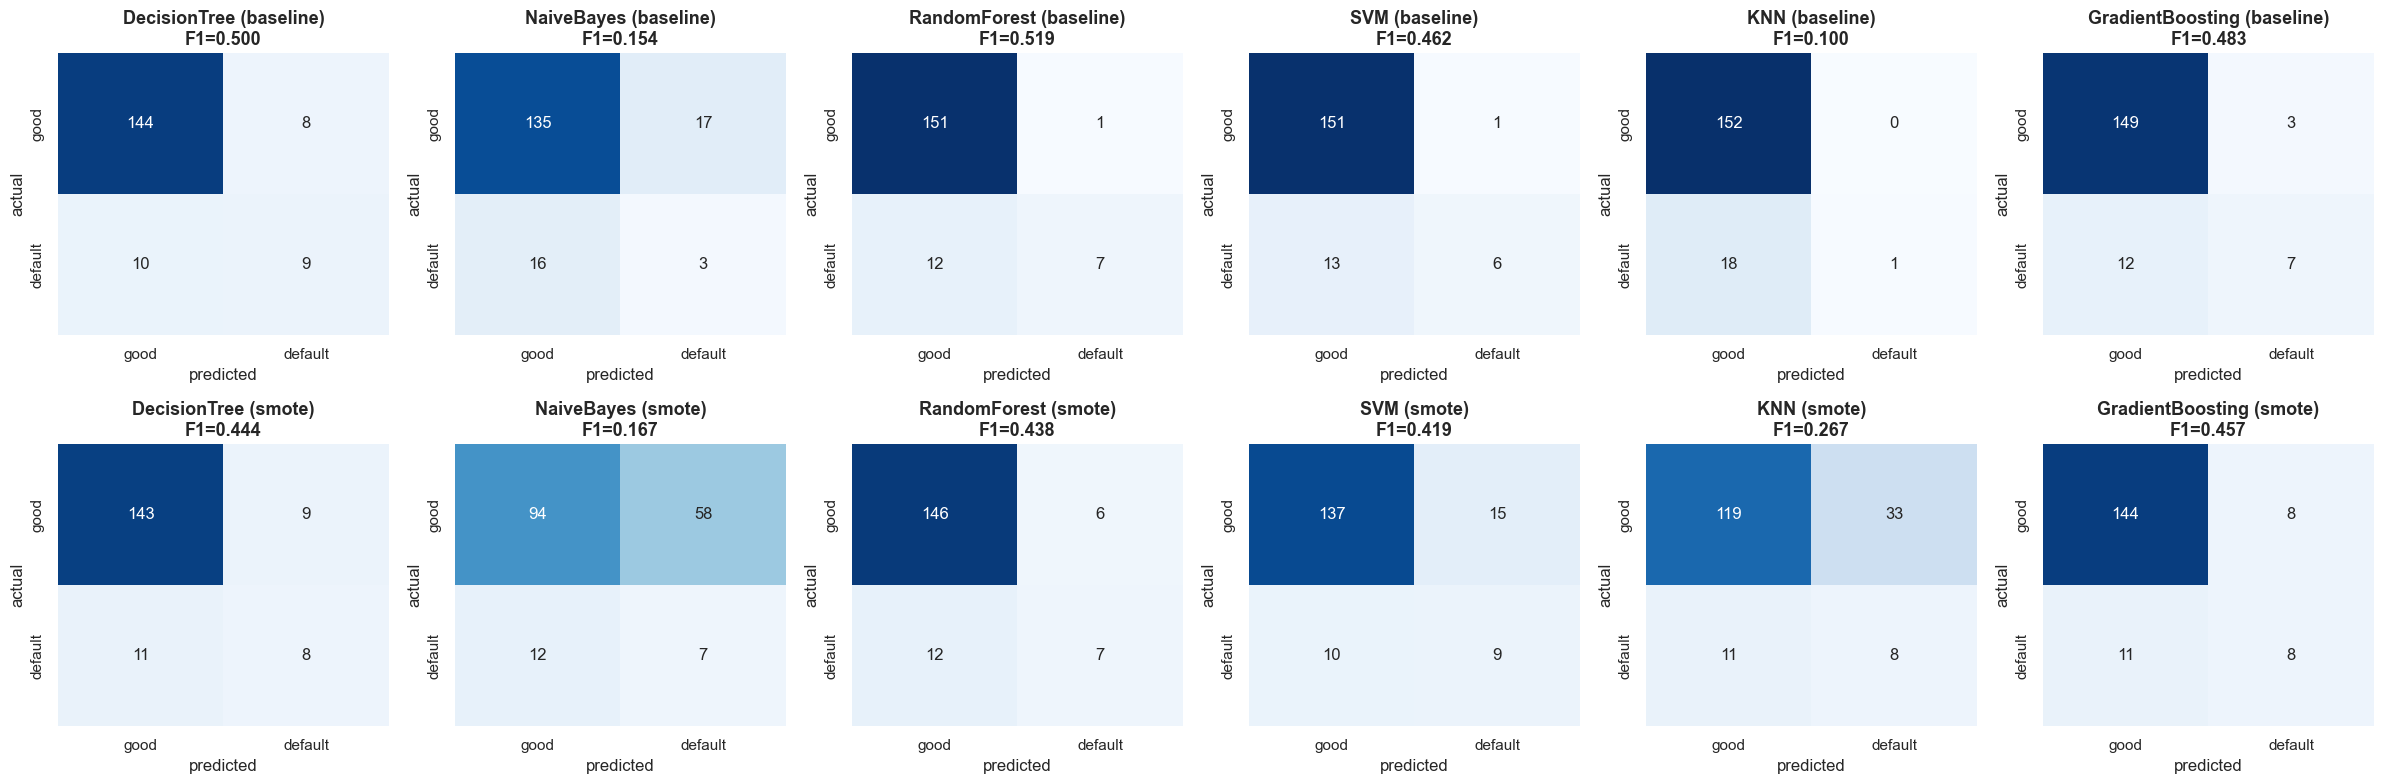

In [10]:
vmax = max(confusion_matrix(y_test, fitted[(n, s)][0]).max()
           for n in models for s in ["baseline", "smote"])
n_cols = len(models)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
for j, name in enumerate(models):
    for i, setting in enumerate(["baseline", "smote"]):
        pred, _, _ = fitted[(name, setting)]
        f1 = res.loc[(res["model"] == name) & (res["setting"] == setting), "f1"].iloc[0]
        sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", annot_kws={"size": 12},
                    cmap="Blues", vmin=0, vmax=vmax, cbar=False,
                    xticklabels=["good", "default"], yticklabels=["good", "default"], ax=axes[i, j])
        axes[i, j].set_title(f"{name} ({setting})\nF1={f1:.3f}")
        axes[i, j].set_xlabel("predicted")
        axes[i, j].set_ylabel("actual")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


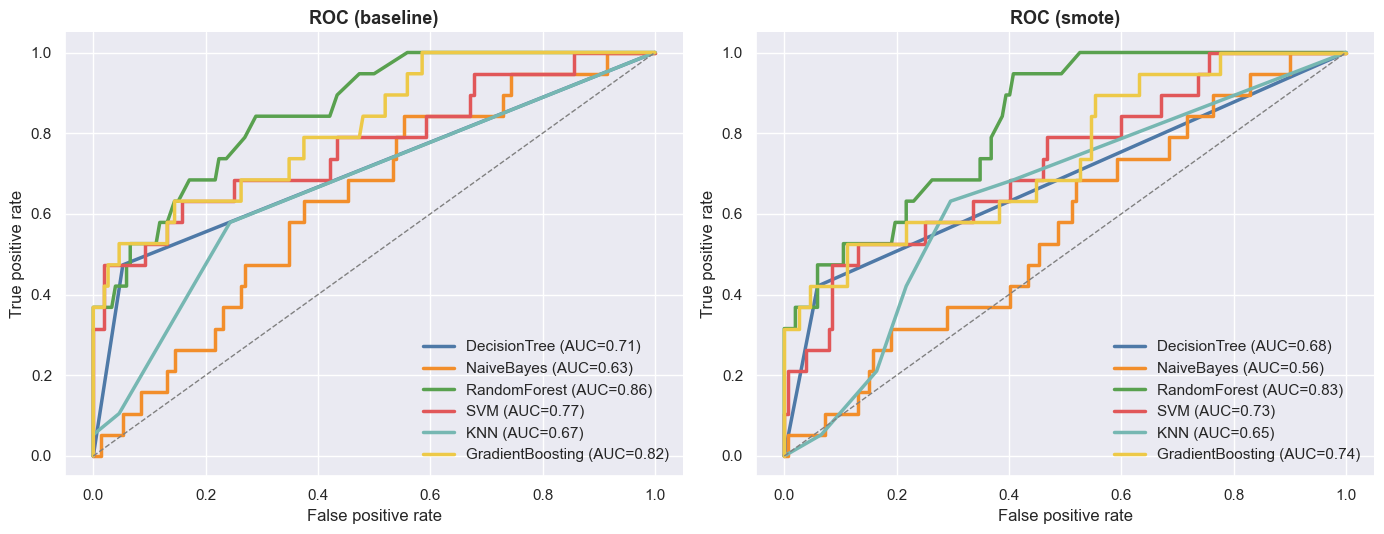

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, setting in enumerate(["baseline", "smote"]):
    for name in models:
        _, proba, _ = fitted[(name, setting)]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = res.loc[(res["model"] == name) & (res["setting"] == setting), "roc_auc"].iloc[0]
        axes[i].plot(fpr, tpr, linewidth=2.5, color=MODEL_COLORS[name], label=f"{name} (AUC={auc:.2f})")
    axes[i].plot([0, 1], [0, 1], color="grey", linewidth=1, linestyle="--")
    axes[i].set_title(f"ROC ({setting})")
    axes[i].set_xlabel("False positive rate")
    axes[i].set_ylabel("True positive rate")
    axes[i].legend(frameon=False)
    sns.despine(ax=axes[i])
plt.tight_layout()
plt.savefig(FIG_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


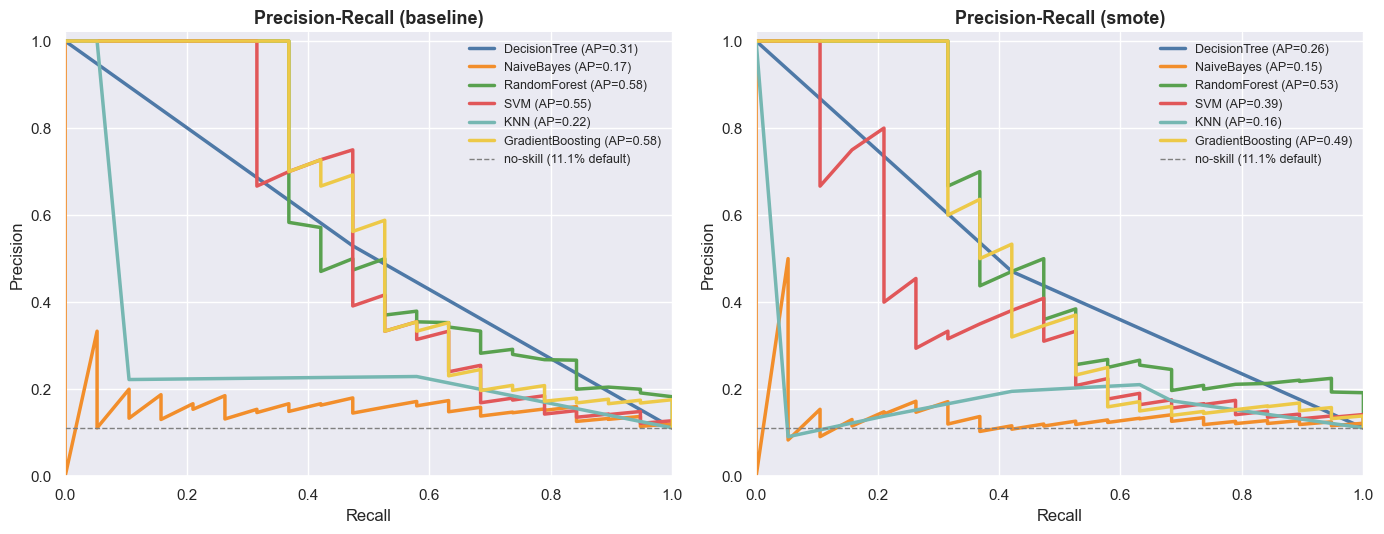

In [12]:
# Precision-recall curves: the honest view at 11% prevalence, where ROC-AUC flatters
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, setting in enumerate(["baseline", "smote"]):
    for name in models:
        _, proba, _ = fitted[(name, setting)]
        prec, rec, _ = precision_recall_curve(y_test, proba)
        axes[i].plot(rec, prec, linewidth=2.5, color=MODEL_COLORS[name],
                     label=f"{name} (AP={average_precision_score(y_test, proba):.2f})")
    axes[i].axhline(y_test.mean(), color="grey", linewidth=1, linestyle="--",
                    label=f"no-skill ({y_test.mean():.1%} default)")
    axes[i].set_title(f"Precision-Recall ({setting})")
    axes[i].set_xlabel("Recall")
    axes[i].set_ylabel("Precision")
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1.02)
    axes[i].legend(frameon=False, fontsize=9)
    sns.despine(ax=axes[i])
plt.tight_layout()
plt.savefig(FIG_DIR / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

min_balance        0.261
balance_at_loan    0.116
txn_per_month      0.071
payments           0.062
amount             0.056
avg_balance        0.051
sum_deposit        0.050
n_deposit          0.044
n_txn              0.040
sum_withdrawal     0.038
max_balance        0.036
std_amount         0.034
avg_amount         0.032
n_withdrawal       0.031
months_active      0.031
age                0.025
duration           0.019
gender_bin         0.005


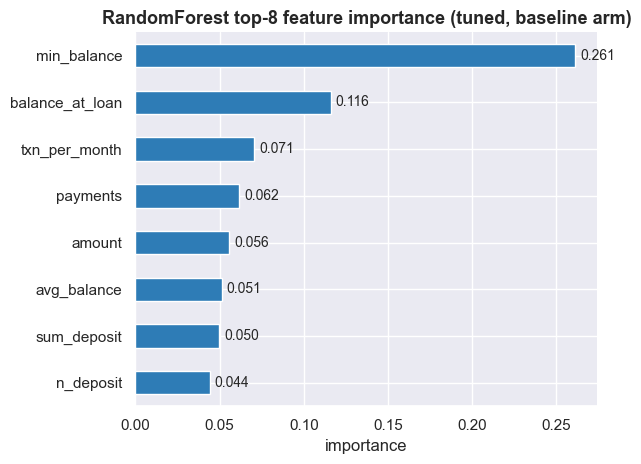

In [13]:
# Feature importance from the tuned Random Forest (baseline arm), not a separate refit
rf_model = searches[("RandomForest", "baseline")].best_estimator_.named_steps["randomforestclassifier"]
imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(imp.round(3).to_string())

top = imp.head(8).sort_values()
ax = top.plot.barh(color=GOOD, edgecolor="white")
ax.set_title("RandomForest top-8 feature importance (tuned, baseline arm)")
ax.set_xlabel("importance")
for i, v in enumerate(top):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / "rf_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
assert len(res) == len(models) * 2, len(res)
assert len(tune_res) == len(models) * 2, len(tune_res)
assert len(cv_res) == len(models) * 2 * 2, len(cv_res)
metric_cols = ["accuracy", "precision", "recall", "f1", "average_precision", "roc_auc"]
assert ((res[metric_cols] >= 0) & (res[metric_cols] <= 1)).all().all()
assert cv_res["cv_f1_mean"].between(0, 1).all()
assert (cv_res["cv_f1_std"] >= 0).all() and (cv_res["cv_ap_std"] >= 0).all()
assert tune_res["inner_cv_f1"].between(0, 1).all()
assert abs(cv_res["cv_f1_mean"].max() - win["cv_f1_mean"]) < 1e-9
for name in ["metrics_comparison.csv", "cv_comparison.csv", "tuning_results.csv"]:
    assert (OUT_DIR / name).exists(), name
assert pickle_path.exists(), pickle_path
print("modeling checks passed")

modeling checks passed


## How to read these outputs

| Artifact | Contents |
|---|---|
| `metrics_comparison.csv` | 12 runs, default hyperparameters, single stratified split. Readable reference. |
| `tuning_results.csv` | 12 rows: search space size, best parameters, inner-CV F1, search time. |
| `cv_comparison.csv` | 24 rows: repeated 5-fold x 10 CV for default and tuned settings on both imbalance arms. **This is the selection table.** |
| `confusion_matrices.png` | 2 x 6 grid at default hyperparameters. |
| `roc_curves.png` | ROC per imbalance arm, default hyperparameters. |
| `pr_curves.png` | Precision-recall curves with Average Precision, the honest metric at 11% prevalence. |
| `cv_selection.png` | Tuning gain per configuration, with the selected model marked. |
| `tuning_curves.png` | F1 against the key hyperparameter for the two strongest model families. |
| `rf_importance.png` | Tuned Random Forest impurity importance. |
| `models/best_*.pkl` | The selected pipeline, fitted on the training split only. |

Average Precision is reported alongside ROC-AUC because with 606 good loans against 76 defaults a ROC-AUC near 0.86 looks stronger than the model is; AP reflects how well the positive class is actually ranked.

Hyperparameters were searched against the whole training split, so the tuned CV scores are mildly optimistic. Nested cross-validation would remove that bias; at 682 rows it was judged not worth the extra runtime, and the bias is small relative to the 50-estimate spread.